5 UZDUOTIS

Importai

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

Parsisiunciam duomenis

In [2]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "META", "NVDA", "NFLX", "ADBE", "ORCL"]
data = {}
for ticker in tickers:
    try:
        stock_data = yf.download(ticker, start="2020-01-01", end="2023-01-01")
        
        if isinstance(stock_data.columns, pd.MultiIndex):
            stock_data.columns = stock_data.columns.get_level_values(0)
       
        if "Adj Close" in stock_data.columns:
            data[ticker] = stock_data["Adj Close"]
        elif "Close" in stock_data.columns:
            data[ticker] = stock_data["Close"]
        else:
            print(f"Unable to find Close or Adj Close column for {ticker}")
    except Exception as e:
        print(f"Unable to obtain data for {ticker}: {e}")

prices = pd.DataFrame(data)

if prices.empty:
    print("Data not obtained.")
else:
    print("Data obtained.")
    print(f"Columns: {prices.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data obtained.
Columns: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'NFLX', 'ADBE', 'ORCL']


STRATEGIJA

Psychological lane

In [3]:
def strategy_psychological_lane(data, round_level):
    # Psichologiniai lygiai, pvz., 100, 200 ir t. t.
    data['Psych_Level'] = (data['Price'] // round_level) * round_level
    data['Signal'] = np.where(data['Price'] > data['Psych_Level'], 1, -1)
    data['Returns'] = data['Signal'].shift(1) * data['Price'].pct_change()
    return data

Optimizavimas

In [4]:
def optimize_psychological_lane(data, round_levels):
    best_level = None
    best_return = -np.inf
    for level in round_levels:
        temp_data = data.copy()
        temp_data = strategy_psychological_lane(temp_data, level)
        total_return = temp_data['Returns'].sum()
        if total_return > best_return:
            best_level = level
            best_return = total_return
    return best_level

Prime number bands

In [5]:
def strategy_prime_number_bands(data, prime_gap):
    primes = [p for p in range(2, 2000) if all(p % d != 0 for d in range(2, int(np.sqrt(p)) + 1))]
    band_start = primes[0]
    band_end = primes[prime_gap]
    data['Prime_Upper'] = band_end
    data['Prime_Lower'] = band_start
    data['Signal'] = np.where(data['Price'] < band_start, 1, np.where(data['Price'] > band_end, -1, 0))
    data['Returns'] = data['Signal'].shift(1) * data['Price'].pct_change()
    return data

Optimizavimas

In [6]:
def optimize_prime_number_bands(data, prime_gaps):
    best_gap = None
    best_return = -np.inf
    for gap in prime_gaps:
        temp_data = data.copy()
        temp_data = strategy_prime_number_bands(temp_data, gap)
        total_return = temp_data['Returns'].sum()
        if total_return > best_return:
            best_gap = gap
            best_return = total_return
    return best_gap

Relative volatility

In [7]:
def strategy_relative_volatility(data, window):
    data['Volatility'] = data['Price'].pct_change().rolling(window=window).std()
    data['Signal'] = np.where(data['Volatility'] < data['Volatility'].rolling(window=window).mean(), 1, -1)
    data['Returns'] = data['Signal'].shift(1) * data['Price'].pct_change()
    return data

Optimizavimas

In [8]:
def optimize_relative_volatility(data, windows):
    best_window = None
    best_return = -np.inf
    for window in windows:
        temp_data = data.copy()
        temp_data = strategy_relative_volatility(temp_data, window)
        total_return = temp_data['Returns'].sum()
        if total_return > best_return:
            best_window = window
            best_return = total_return
    return best_window

SKAICIUOJAM GRAZA

In [9]:
strategy_results = {}
portfolio_returns = pd.DataFrame(index=prices.index)
for ticker in tickers:
    stock_data = prices[[ticker]].rename(columns={ticker: "Price"})
    
    if stock_data['Price'].isna().all():
        print(f"{ticker} nepakanka duomenų.")
        continue
    
    best_psych_level = optimize_psychological_lane(stock_data, range(10, 100, 10))
    strategy_psych_lane_data = strategy_psychological_lane(stock_data.copy(), best_psych_level)
    
    best_prime_gap = optimize_prime_number_bands(stock_data, range(2, 50))
    strategy_prime_band_data = strategy_prime_number_bands(stock_data.copy(), best_prime_gap)
    
    best_volatility_window = optimize_relative_volatility(stock_data, range(5, 50))
    strategy_relative_volatility_data = strategy_relative_volatility(stock_data.copy(), best_volatility_window)
    
    combined_returns = (
        strategy_psych_lane_data['Returns'] +
        strategy_prime_band_data['Returns'] +
        strategy_relative_volatility_data['Returns']
    )
    portfolio_returns[ticker] = combined_returns

Grafikas

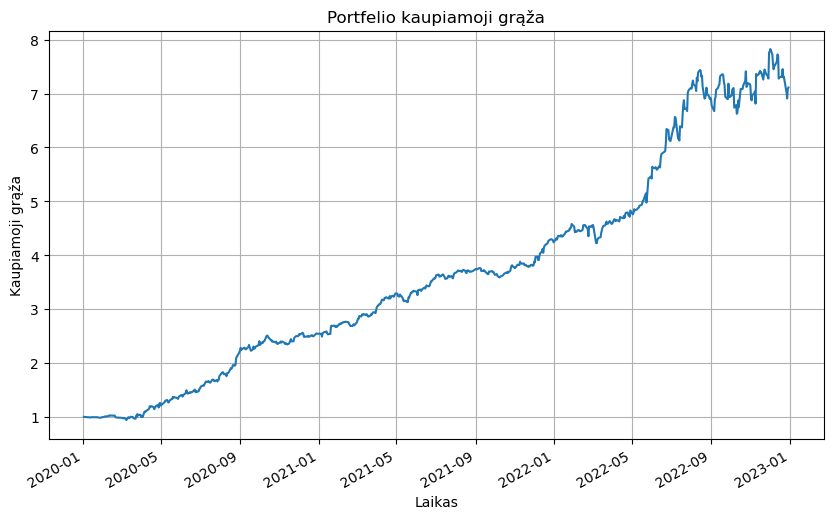

In [10]:
if not portfolio_returns.empty:
    portfolio_returns['Total_Return'] = portfolio_returns.mean(axis=1)
    portfolio_returns['Cumulative_Return'] = (1 + portfolio_returns['Total_Return']).cumprod()
    portfolio_returns['Cumulative_Return'].plot(title="Portfelio kaupiamoji grąža", figsize=(10, 6))
    plt.xlabel("Laikas")
    plt.ylabel("Kaupiamoji grąža")
    plt.grid()
    plt.show()
else:
    print("Nėra duomenų grafiko braižymui.")


KORELIACIJOS MATRICA

Koreliacijos matrica:


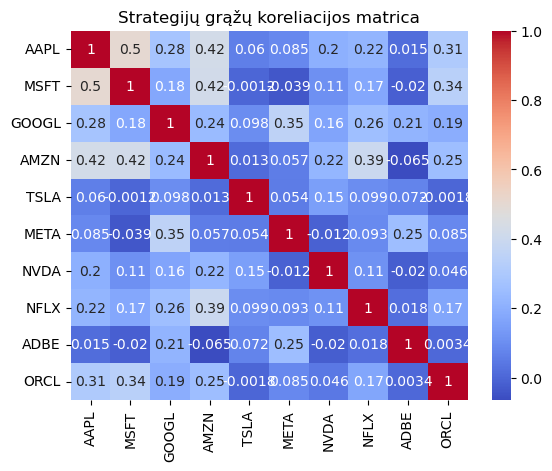

In [11]:
if not portfolio_returns.empty:
    correlation_matrix = portfolio_returns[tickers].corr()
    print("Koreliacijos matrica:")
    #print(correlation_matrix)

    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', cbar=True)
    plt.title("Strategijų grąžų koreliacijos matrica")
    plt.show()
else:
    print("Nėra duomenų koreliacijos matricai.")